In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')


# ================================================================
#  Step 1: 特征工程
# ================================================================
def feature_engineering(full: pd.DataFrame) -> pd.DataFrame:
    df = full.copy()
    spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

    # ════════════════════════════════════════════════════════════════
    # 模块 1：PassengerId 解析
    # ════════════════════════════════════════════════════════════════
    df['GroupId']     = df['PassengerId'].str.split('_').str[0].astype(int)
    df['GroupMember'] = df['PassengerId'].str.split('_').str[1].astype(int)  # v2 保留
    df['GroupSize']   = df.groupby('GroupId')['PassengerId'].transform('count')
    df['IsAlone']     = (df['GroupSize'] == 1).astype(int)
    df['GroupId_region'] = pd.qcut(
        df['GroupId'],
        q=5,
        labels=[1, 2, 3, 4, 5]
    ).astype(float)

    # ════════════════════════════════════════════════════════════════
    # 模块 2：Cabin 解析
    # ════════════════════════════════════════════════════════════════
    df['Cabin']       = df['Cabin'].fillna('U/0/U')
    df['Deck']        = df['Cabin'].str.split('/').str[0]
    df['CabinNum']    = df['Cabin'].str.split('/').str[1].astype(float)
    df['Side']        = df['Cabin'].str.split('/').str[2]
    df['CabinRegion'] = pd.cut(
        df['CabinNum'],
        bins=[0, 300, 600, 900, 1200, 1800],
        labels=[1, 2, 3, 4, 5]
    ).astype(float)

    # df['GroupId_Deck'] = df['GroupId_region'].astype(str) + '_' + df['Deck']

    df['CabinNum_pct_inDeck'] = df.groupby('Deck')['CabinNum'].transform(
        lambda x: x.rank(pct=True)
    )
    df.loc[df['Deck'] == 'U', 'CabinNum_pct_inDeck'] = -1

    # ════════════════════════════════════════════════════════════════
    # 模块 3：布尔列处理
    # ════════════════════════════════════════════════════════════════
    for col in ['CryoSleep', 'VIP']:
        df[col] = df[col].map(
            {True: 1, False: 0, 'True': 1, 'False': 0}
        ).fillna(-1)

    # CryoSleep 修正
    has_spend = df[spend_cols].sum(axis=1, min_count=1) > 0
    df.loc[has_spend & (df['CryoSleep'] == -1), 'CryoSleep'] = 0

    # ════════════════════════════════════════════════════════════════
    # 模块 4：消费特征
    # ════════════════════════════════════════════════════════════════
    for col in spend_cols:
        median_val = df.loc[df['CryoSleep'] != 1, col].median()
        df.loc[df['CryoSleep'] == 1, col] = df.loc[df['CryoSleep'] == 1, col].fillna(0)
        df[col] = df[col].fillna(median_val)

    df['CryoSleep'] = df['CryoSleep'].replace(-1, 0)

    df['TotalSpend']  = df[spend_cols].sum(axis=1)
    df['LuxurySpend'] = df[['Spa', 'VRDeck', 'RoomService']].sum(axis=1)
    df['BasicSpend']  = df[['FoodCourt', 'ShoppingMall']].sum(axis=1)
    df['NoSpend']     = (df['TotalSpend'] == 0).astype(int)
    df['SpendCount']  = (df[spend_cols] > 0).sum(axis=1)

    # 与 v2 一致：消费 ratio（去掉 Spa_ratio）+ log
    for col in ['RoomService', 'FoodCourt', 'ShoppingMall', 'VRDeck']:
        df[f'{col}_ratio'] = df[col] / (df['TotalSpend'] + 1)
    for col in spend_cols + ['TotalSpend', 'LuxurySpend', 'BasicSpend']:
        df[f'log_{col}'] = np.log1p(df[col])

    # ════════════════════════════════════════════════════════════════
    # 模块 5：团体聚合
    # ════════════════════════════════════════════════════════════════
    for col in spend_cols + ['TotalSpend']:
        grp = df.groupby('GroupId')[col]
        df[f'Grp_{col}_mean'] = grp.transform('mean')
        df[f'Grp_{col}_sum']  = grp.transform('sum')
        df[f'Grp_{col}_std']  = grp.transform('std').fillna(0)

    df['Grp_Cryo_ratio'] = df.groupby('GroupId')['CryoSleep'].transform('mean')
    df['Grp_VIP_ratio']  = df.groupby('GroupId')['VIP'].transform('mean')
    df['SpendPerMember'] = df['TotalSpend'] / df['GroupSize']

    # ════════════════════════════════════════════════════════════════
    # 模块 6：年龄特征
    # ════════════════════════════════════════════════════════════════
    df['HomePlanet']  = df['HomePlanet'].fillna('Unknown')
    df['Destination'] = df['Destination'].fillna('Unknown')

    df['Age'] = df.groupby(['HomePlanet', 'Deck'])['Age'].transform(
        lambda x: x.fillna(x.median())
    )
    df['Age'] = df['Age'].fillna(df['Age'].median())
    #df['IsChild'] = (df['Age'] < 13).astype(int)
    df['AgeGroup'] = pd.cut(
        df['Age'],
        bins=[0, 12, 18, 30, 45, 65, 200],
        labels=['Child', 'Teen', 'YoungAdult', 'Adult', 'MiddleAge', 'Senior']
    ).astype(str)

    # ════════════════════════════════════════════════════════════════
    # 模块 7：交叉特征
    # ════════════════════════════════════════════════════════════════
    df['DeckSide']   = df['Deck'] + '_' + df['Side']
    df['Route']      = df['HomePlanet'] + '_to_' + df['Destination']
    df['VIP_Planet'] = df['VIP'].astype(str) + '_' + df['HomePlanet']  # v2 原有

    print(f"✅ 特征工程完成 | 总特征数: {df.shape[1]}")
    return df

# ================================================================
#  调用示例
# ================================================================
if __name__ == '__main__':
    train = pd.read_csv('train.csv')
    test  = pd.read_csv('test.csv')

    y     = train['Transported'].astype(int)
    full  = pd.concat([train.drop('Transported', axis=1), test], ignore_index=True)
    full  = feature_engineering(full)

    n_train   = len(train)
    X_train   = full.iloc[:n_train].drop(columns=['PassengerId'])
    X_test    = full.iloc[n_train:].drop(columns=['PassengerId'])
    test_ids  = full.iloc[n_train:]['PassengerId']

    cat_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
    print(f"\n训练集: {X_train.shape} | 测试集: {X_test.shape}")
    print(f"类别特征: {cat_features}")

✅ 特征工程完成 | 总特征数: 65

训练集: (8693, 64) | 测试集: (4277, 64)
类别特征: ['HomePlanet', 'Cabin', 'Destination', 'Name', 'Deck', 'Side', 'AgeGroup', 'DeckSide', 'Route', 'VIP_Planet']


In [2]:
CB_PARAMS = {
    'iterations'         : 3000,
    'learning_rate'      : 0.03,
    'depth'              : 5,
    'l2_leaf_reg'        : 3,
    'subsample'          : 0.85,
    'colsample_bylevel'  : 0.75,
    'loss_function'      : 'Logloss',
    'eval_metric'        : 'Accuracy',
    'early_stopping_rounds': 200,
    'random_seed'        : 42,
    'verbose'            : 0,
}

DROP_COLS = ['PassengerId', 'Name', 'Cabin', 'Transported']

def prepare_catboost(full, train_len, y):
    df = full.drop(columns=DROP_COLS, errors='ignore').copy()

    cat_cols = [c for c in df.columns if df[c].dtype == 'object' or str(df[c].dtype) == 'category']
    for c in cat_cols:
        df[c] = df[c].fillna('Unknown')

    X      = df.iloc[:train_len]
    X_test = df.iloc[train_len:]

    return X, X_test, y, cat_cols

if __name__ == '__main__':
    train = pd.read_csv('train.csv')
    test  = pd.read_csv('test.csv')

    y     = train['Transported'].astype(int)
    full  = pd.concat([train.drop('Transported', axis=1), test], ignore_index=True)
    full  = feature_engineering(full)

    n_train   = len(train)
    X_train   = full.iloc[:n_train].drop(columns=['PassengerId'])
    X_test    = full.iloc[n_train:].drop(columns=['PassengerId'])
    test_ids  = full.iloc[n_train:]['PassengerId']

    cat_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
    print(f"\n训练集: {X_train.shape} | 测试集: {X_test.shape}")
    print(f"类别特征: {cat_features}")

X_cb, X_test_cb, _, cat_cols_cb = prepare_catboost(full, n_train, y)

print(f"特征维度: {X_cb.shape}")
print(f"类别特征数: {len(cat_cols_cb)}")

✅ 特征工程完成 | 总特征数: 65

训练集: (8693, 64) | 测试集: (4277, 64)
类别特征: ['HomePlanet', 'Cabin', 'Destination', 'Name', 'Deck', 'Side', 'AgeGroup', 'DeckSide', 'Route', 'VIP_Planet']
特征维度: (8693, 62)
类别特征数: 8


In [3]:
def _finalize_training_plot(fold_histories, n_splits):
    metric_name = "Accuracy"

    fig = plt.figure(figsize=(20, 8))
    gs = gridspec.GridSpec(2, n_splits, figure=fig, hspace=0.4, wspace=0.3)

    colors = plt.cm.Set2(np.linspace(0, 1, len(fold_histories)))

    for i, hist in enumerate(fold_histories):
        ax = fig.add_subplot(gs[0, i])
        iters = range(1, len(hist['train']) + 1)

        ax.plot(iters, hist['train'], color='#2196F3', linewidth=1.2, label='Train', alpha=0.8)
        ax.plot(iters, hist['val'],   color='#F44336', linewidth=1.2, label='Val',   alpha=0.8)

        best_iter = hist['best_iter']
        best_val  = hist['val'][best_iter]
        ax.axvline(x=best_iter, color='green', linestyle='--', linewidth=1, alpha=0.7)
        ax.scatter([best_iter], [best_val], color='green', s=60, zorder=5)
        ax.annotate(f'best={best_iter}\n{best_val:.4f}',
                    xy=(best_iter, best_val),
                    xytext=(best_iter + len(iters)*0.05, best_val - 0.02),
                    fontsize=7, color='green')

        ax.set_title(f'Fold {i+1}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Iteration', fontsize=8)
        ax.set_ylabel(metric_name, fontsize=8)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

    ax_compare = fig.add_subplot(gs[1, :n_splits//2])
    for i, hist in enumerate(fold_histories):
        iters = range(1, len(hist['val']) + 1)
        ax_compare.plot(iters, hist['val'], color=colors[i], linewidth=1.2,
                         label=f'Fold {i+1} (best@{hist["best_iter"]})', alpha=0.85)
    ax_compare.set_title('All Folds - Validation Curve Comparison',
                          fontsize=10, fontweight='bold')
    ax_compare.set_xlabel('Iteration', fontsize=8)
    ax_compare.set_ylabel(metric_name, fontsize=8)
    ax_compare.legend(fontsize=7)
    ax_compare.grid(True, alpha=0.3)

    ax_gap = fig.add_subplot(gs[1, n_splits//2:])
    for i, hist in enumerate(fold_histories):
        iters = range(1, len(hist['train']) + 1)
        gap = np.array(hist['train']) - np.array(hist['val'])
        ax_gap.plot(iters, gap, color=colors[i], linewidth=1.2, label=f'Fold {i+1}', alpha=0.85)
    ax_gap.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    ax_gap.axhline(y=0.05, color='orange', linestyle='--', linewidth=1, label='Gap=0.05')
    ax_gap.set_title('Train-Val Gap', fontsize=10, fontweight='bold')
    ax_gap.set_xlabel('Iteration', fontsize=8)
    ax_gap.set_ylabel(f'Train {metric_name} - Val {metric_name}', fontsize=8)
    ax_gap.legend(fontsize=7)
    ax_gap.grid(True, alpha=0.3)

    fig.suptitle("CatBoost Training Dashboard", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig("catboost_training_summary.png", dpi=150, bbox_inches='tight')
    plt.show()

Training CatBoost ...


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

  Fold 1 | Acc=0.8258 | AUC=0.9093 | best_iter=900


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

  Fold 2 | Acc=0.8097 | AUC=0.8963 | best_iter=397


...

  Fold 3 | Acc=0.8223 | AUC=0.9032 | best_iter=448


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

  Fold 4 | Acc=0.8211 | AUC=0.9108 | best_iter=251


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

  Fold 5 | Acc=0.8096 | AUC=0.8959 | best_iter=569


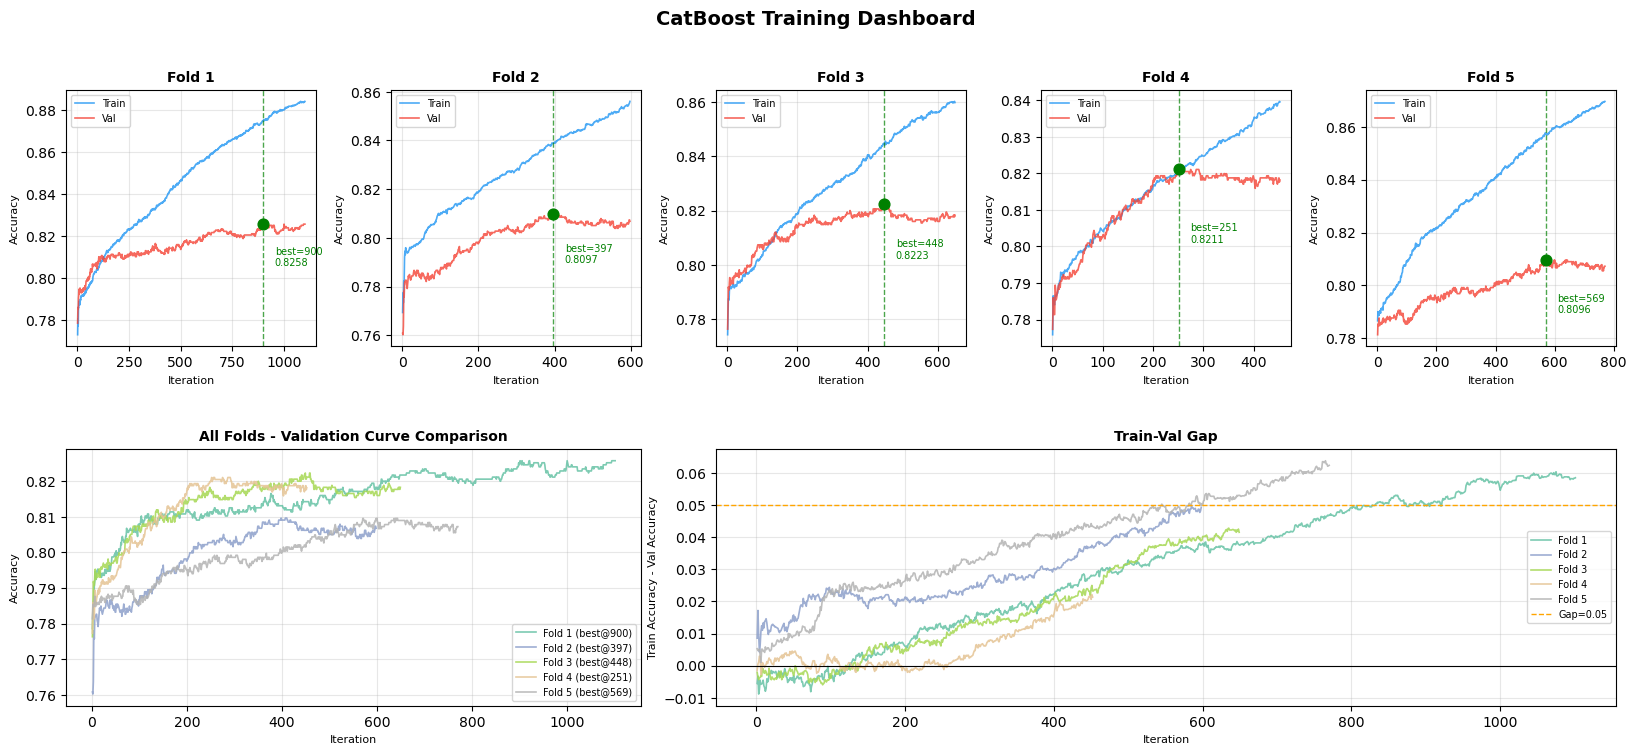

  [CatBoost] OOF Accuracy = 0.8177 | OOF AUC=0.9028



In [4]:
def train_catboost_kfold(X, X_test, y, cat_cols, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    oof  = np.zeros(len(X))
    pred = np.zeros(len(X_test))

    fold_histories = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr,  X_val  = X.iloc[tr_idx],  X.iloc[val_idx]
        y_tr,  y_val  = y.iloc[tr_idx],  y.iloc[val_idx]

        tr_pool  = Pool(X_tr,  y_tr,  cat_features=cat_cols)
        val_pool = Pool(X_val, y_val, cat_features=cat_cols)

        model = CatBoostClassifier(**CB_PARAMS)
        model.fit(tr_pool, eval_set=val_pool, use_best_model=True, plot=True)

        evals_result = model.evals_result_
        train_metric = list(evals_result['learn'].values())[0]
        val_metric   = list(evals_result['validation'].values())[0]
        fold_histories.append({
            'train': train_metric,
            'val':   val_metric,
            'best_iter': model.best_iteration_
        })

        oof[val_idx] = model.predict_proba(X_val)[:, 1]
        pred        += model.predict_proba(X_test)[:, 1] / n_splits

        score = accuracy_score(y_val, (oof[val_idx] > 0.5).astype(int))
        auc = roc_auc_score(y_val, oof[val_idx])
        print(f"  Fold {fold+1} | Acc={score:.4f} | AUC={auc:.4f} "
              f"| best_iter={model.best_iteration_}")

    _finalize_training_plot(fold_histories, n_splits)

    oof_score = accuracy_score(y, (oof > 0.5).astype(int))
    oof_auc = roc_auc_score(y, oof)
    print(f"  [CatBoost] OOF Accuracy = {oof_score:.4f} | OOF AUC={oof_auc:.4f}\n")
    return oof, pred, fold_histories

print("=" * 55)
print("Training CatBoost ...")
cb_oof, cb_pred, cb_histories = train_catboost_kfold(X_cb, X_test_cb, y, cat_cols_cb)

In [5]:
# 搜索最优阈值
thresholds = np.arange(0.40, 0.60, 0.005)
scores = [accuracy_score(y, (cb_oof > t).astype(int)) for t in thresholds]
best_t = thresholds[np.argmax(scores)]
best_s = max(scores)

print(f"最优阈值: {best_t:.3f}")
print(f"最优 OOF Accuracy: {best_s:.4f}")

# 生成提交
final_pred = (cb_pred > best_t).astype(bool)

submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Transported': final_pred
})
submission.to_csv('submission_catboost1.csv', index=False)

print(f"提交文件: submission_catboost1.csv")
print(f"阈值: {best_t:.3f}")
print(f"预测分布:\n{submission['Transported'].value_counts()}")

最优阈值: 0.500
最优 OOF Accuracy: 0.8177
提交文件: submission_catboost1.csv
阈值: 0.500
预测分布:
Transported
True     2272
False    2005
Name: count, dtype: int64
